=== Path Check ===
  OK      S1Hand                     → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                  → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING Weak S1 (unlabeled pool)   → None
  MISSING Weak label masks           → None

Deriving image-level labels from masks (flooded = water fraction ≥ 0.01) ...
  Chips: 441  (293 flooded | 148 non-flooded)

=== Baseline Training Sets ===
  Supervised-only  : 176 chips  (121 flooded | 55 non-flooded)
  Full-supervision : 352 chips  (234 flooded | 118 non-flooded)
  Val              : 89 chips  (59 flooded | 30 non-flooded)
  Extra labels for full-supervision ← hidden hand-mask labels (exact)

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Runs    : 2 × 50 epochs (supervised-only, full-supervision)

=== Building VGG-16 ===
  Total params     : 134.3M  (paper states ~138M)
  Inpu

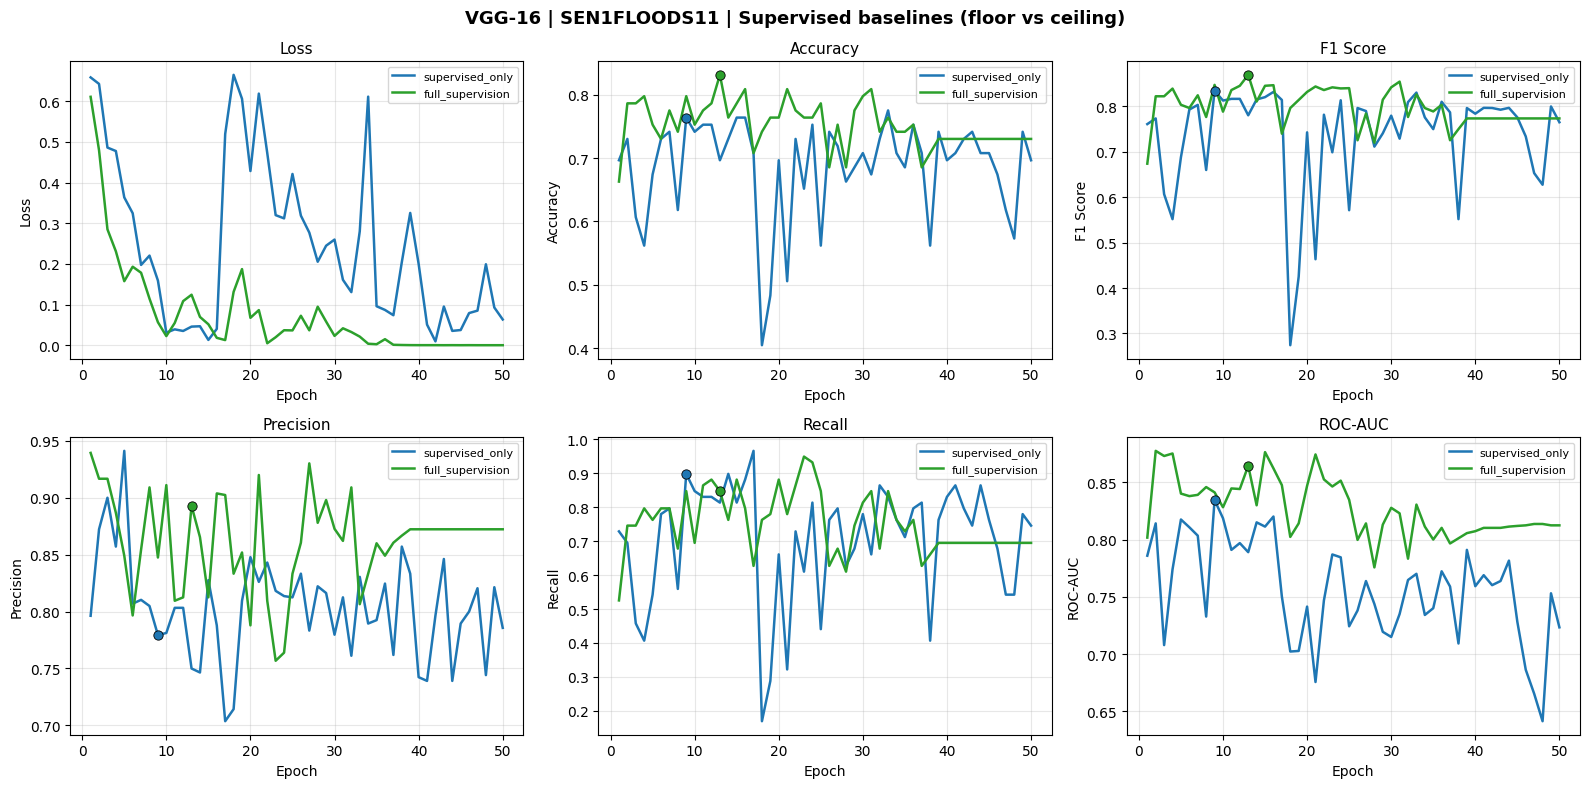

Saved → vgg16_sen1floods11_baselines_curves.png

✓ All done.


In [6]:
import os, copy, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── 1. PATHS — auto-detect the dataset layout ──────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download("smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    """Walk directories only (cheap) and return the first match by name."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR        = find_dir(ROOT, "S1Hand")
LABEL_DIR     = find_dir(ROOT, "LabelHand")
WEAK_DIR      = find_dir(ROOT, "S1Weak")            # weakly-labeled S1 chips
WEAK_LBL_DIR  = (find_dir(ROOT, "S1OtsuLabelWeak")  # weak reference masks
                 or find_dir(ROOT, "S2IndexLabelWeak"))

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("Weak S1 (unlabeled pool)", WEAK_DIR),
                ("Weak label masks", WEAK_LBL_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<26} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None, \
    "Could not locate S1Hand / LabelHand folders — check dataset root."

# ── 2. Derive image-level labels from pixel masks ──────────────────────
#  (identical constants and RNG call order to the λ script → same splits)
FLOOD_THRESHOLD    = 0.01   # chip = flooded if ≥1% of valid pixels are water
UNLABELED_FRACTION = 0.50   # fallback only (when no weak S1 folder exists)
MAX_UNLABELED      = 1500   # cap unlabeled pool (RAM guard)

def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print("\nDeriving image-level labels from masks "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")

all_samples = []                      # (s1_path, label)
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:                    # chip is entirely no-data
        continue
    all_samples.append((str(s1_path), int(wf >= FLOOD_THRESHOLD)))

flooded_s    = [s for s in all_samples if s[1] == 1]
nonflooded_s = [s for s in all_samples if s[1] == 0]
print(f"  Chips: {len(all_samples)}  "
      f"({len(flooded_s)} flooded | {len(nonflooded_s)} non-flooded)")

# ── 3. 80/20 labeled split (same RNG order as the λ script) ────────────
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

TRAIN_SAMPLES = f_train + nf_train
VAL_SAMPLES   = f_val   + nf_val

# ── 4. Unlabeled pool (same RNG order as the λ script) ─────────────────
if WEAK_DIR is not None:
    UNLABELED_PATHS = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(UNLABELED_PATHS)
    UNLABELED_PATHS = UNLABELED_PATHS[:MAX_UNLABELED]
    unl_source = f"weakly-labeled S1 chips ({WEAK_DIR.name})"
else:
    random.shuffle(TRAIN_SAMPLES)
    cut             = int((1 - UNLABELED_FRACTION) * len(TRAIN_SAMPLES))
    UNLABELED_PATHS = [p for p, _ in TRAIN_SAMPLES[cut:]]
    HIDDEN_TRUE     = {p: l for p, l in TRAIN_SAMPLES[cut:]}
    TRAIN_SAMPLES   = TRAIN_SAMPLES[:cut]
    unl_source = (f"{UNLABELED_FRACTION:.0%} of train chips "
                  "(labels discarded — no weak S1 folder found)")

# ── 4b. True labels for the unlabeled pool (for FULL-SUPERVISION) ──────
UNLABELED_TRUE = {}
if WEAK_DIR is None:
    UNLABELED_TRUE = HIDDEN_TRUE
    ref_source = "hidden hand-mask labels (exact)"
elif WEAK_LBL_DIR is not None:
    weak_suffix = f"_{WEAK_LBL_DIR.name}.tif"
    s1w_suffix  = f"_{WEAK_DIR.name}.tif"
    print(f"\nDeriving labels for the unlabeled pool "
          f"from {WEAK_LBL_DIR.name} masks ...")
    for p in UNLABELED_PATHS:
        stem = Path(p).name.replace(s1w_suffix, "")
        wm   = WEAK_LBL_DIR / f"{stem}{weak_suffix}"
        if not wm.exists():
            continue
        wf = water_fraction(wm)
        if wf is not None:
            UNLABELED_TRUE[p] = int(wf >= FLOOD_THRESHOLD)
    ref_source = f"weak masks ({WEAK_LBL_DIR.name}, approximate)"
else:
    ref_source = "NONE — full-supervision baseline not possible"

# ── 5. The two baseline training sets ──────────────────────────────────
SUPERVISED_ONLY_SET = list(TRAIN_SAMPLES)
FULL_SUPERVISION_SET = list(TRAIN_SAMPLES) + \
    [(p, UNLABELED_TRUE[p]) for p in UNLABELED_PATHS if p in UNLABELED_TRUE]

def class_counts(samples):
    f  = sum(1 for _, l in samples if l == 1)
    nf = sum(1 for _, l in samples if l == 0)
    return f, nf

print(f"\n=== Baseline Training Sets ===")
for name, s in [("Supervised-only", SUPERVISED_ONLY_SET),
                ("Full-supervision", FULL_SUPERVISION_SET)]:
    f, nf = class_counts(s)
    print(f"  {name:<17}: {len(s)} chips  ({f} flooded | {nf} non-flooded)")
print(f"  Val              : {len(VAL_SAMPLES)} chips  "
      f"({class_counts(VAL_SAMPLES)[0]} flooded | "
      f"{class_counts(VAL_SAMPLES)[1]} non-flooded)")
print(f"  Extra labels for full-supervision ← {ref_source}")

# ── 6. Fixed hyper-parameters (identical to the λ script) ──────────────
IMG_SIZE  = 224
BATCH     = 16
LR        = 1e-4
E         = 50
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nDevice  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Runs    : 2 × {E} epochs (supervised-only, full-supervision)")

# ── 7. SAR chip loading → 3-channel tensor (identical) ─────────────────
DB_MIN, DB_MAX = -50.0, 1.0     # typical Sentinel-1 backscatter range (dB)
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    """2-band SAR GeoTIFF → normalized 3×224×224 float tensor."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)          # (2, H, W)
    arr = np.nan_to_num(arr, nan=DB_MIN)             # no-data → floor
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)         # dB → [0, 1]
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])        # (3, H, W)
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

# ── 8. Dataset class ───────────────────────────────────────────────────
class LabeledDS(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return load_s1_tensor(path), torch.tensor(lbl, dtype=torch.float32)

val_ldr = DataLoader(LabeledDS(VAL_SAMPLES), batch_size=BATCH,
                     shuffle=False, num_workers=2, pin_memory=True)

def make_train_loader(samples):
    """Weighted sampler per training set (same recipe as the λ script)."""
    f, nf = class_counts(samples)
    n     = len(samples)
    cw    = [n/(2*nf), n/(2*f)]
    sw    = [cw[int(l)] for _, l in samples]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(LabeledDS(samples), batch_size=BATCH, sampler=sampler,
                      num_workers=2, pin_memory=True)

# ── 9. Build VGG-16 (identical to the λ script) ────────────────────────
#  Architecture (as per paper):
#    Conv1: 64  filters ×2  + MaxPool
#    Conv2: 128 filters ×2  + MaxPool
#    Conv3: 256 filters ×3  + MaxPool
#    Conv4: 512 filters ×3  + MaxPool
#    Conv5: 512 filters ×3  + MaxPool
#    FC: 4096 → 4096 → 1   (binary classification)
#    Kernel: 3×3, stride=1 | MaxPool: 2×2
def build_vgg16():
    """
    VGG-16 with pretrained ImageNet weights.
    Replace final FC: 4096 → 1 (binary sigmoid output).
    """
    m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(4096, 1)   # 4096 → 1
    return m

_probe = build_vgg16()
total_p = sum(p.numel() for p in _probe.parameters())
print(f"\n=== Building VGG-16 ===")
print(f"  Total params     : {total_p/1e6:.1f}M  (paper states ~138M)")
print(f"  Input            : 3 × {IMG_SIZE} × {IMG_SIZE}")
print(f"  Output           : 1 node (BCEWithLogitsLoss)")
del _probe

# ── 10. Evaluation (identical) ─────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 11. Plain supervised training run ──────────────────────────────────
def train_supervised(run_name, samples):
    """Standard supervised training: E epochs, labeled data only.
    Same optimizer/loss/eval as the λ script — just no Phase B/C."""
    torch.manual_seed(SEED)        # same init for both baselines
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

    model     = build_vgg16().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    train_ldr = make_train_loader(samples)

    history    = []
    best_f1    = -1
    best_epoch = -1
    best_row   = {}
    best_state = None

    print(f"\n{'═'*88}")
    print(f"  VGG-16  |  {run_name}  |  {len(samples)} train chips  |  "
          f"{E} epochs")
    print(f"{'═'*88}")
    print(f"{'Ep':>3} │ {'Loss':>8} │ {'Acc':>6} │ {'F1':>6} │ "
          f"{'Prec':>6} │ {'Rec':>6} │ {'AUC':>6}")
    print(f"{'─'*88}")

    for ep in range(E):
        model.train()
        total_loss, n_batches = 0.0, 0
        for imgs, lbls in train_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        acc, f1, prec, rec, roc = evaluate(model, val_ldr)

        row = dict(run=run_name, epoch=ep+1, loss=round(avg_loss,4),
                   accuracy=round(acc,4), f1=round(f1,4),
                   precision=round(prec,4), recall=round(rec,4),
                   roc_auc=round(roc,4))
        history.append(row)

        print(f"{ep+1:3d} │ {avg_loss:8.4f} │ {acc:6.4f} │ {f1:6.4f} │ "
              f"{prec:6.4f} │ {rec:6.4f} │ {roc:6.4f}")

        if f1 > best_f1:
            best_f1=f1; best_epoch=ep+1
            best_row=row.copy()
            best_state=copy.deepcopy(model.state_dict())

    print(f"{'─'*88}")
    print(f"  ★ Best epoch {best_epoch}  |  "
          f"Acc={best_row['accuracy']:.4f}  F1={best_row['f1']:.4f}  "
          f"Prec={best_row['precision']:.4f}  Rec={best_row['recall']:.4f}  "
          f"AUC={best_row['roc_auc']:.4f}")

    return history, best_row, best_state

# ── 12. Run both baselines ─────────────────────────────────────────────
print("\n\n" + "█"*88)
print("  SUPERVISED BASELINES  —  VGG-16  |  SEN1FLOODS11")
print("█"*88)

RUNS = [("supervised_only",  SUPERVISED_ONLY_SET),
        ("full_supervision", FULL_SUPERVISION_SET)]

all_history  = []
summary_rows = []
best_states  = {}

for run_name, samples in RUNS:
    hist, best_row, best_state = train_supervised(run_name, samples)
    all_history.extend(hist)
    best_row["n_train"] = len(samples)
    summary_rows.append(best_row)
    best_states[run_name] = best_state

# ── 13. Summary table ──────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)

print("\n\n" + "═"*88)
print("  BASELINE SUMMARY — best epoch per run (val F1)")
print("═"*88)
print(f"{'Run':<18} │ {'#Train':>6} │ {'Epoch':>5} │ {'Acc':>6} │ "
      f"{'F1':>6} │ {'Prec':>6} │ {'Rec':>6} │ {'AUC':>6}")
print("─"*88)
for _, r in summary_df.iterrows():
    print(f"{r['run']:<18} │ {r['n_train']:>6} │ {r['epoch']:>5} │ "
          f"{r['accuracy']:>6.4f} │ {r['f1']:>6.4f} │ {r['precision']:>6.4f} │ "
          f"{r['recall']:>6.4f} │ {r['roc_auc']:>6.4f}")
print("═"*88)
print("\nHow to read this against the λ sweep:")
print("  • supervised_only  = FLOOR — SSL runs must beat this to matter")
print("  • full_supervision = CEILING — SSL with perfect pseudo-labels")

# ── 14. Save ───────────────────────────────────────────────────────────
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
all_df = pd.DataFrame(all_history)
all_df.to_csv(f"{OUT}/vgg16_sen1floods11_baselines_history.csv",
              index=False)
summary_df.to_csv(f"{OUT}/vgg16_sen1floods11_baselines_summary.csv",
                  index=False)
for run_name, state in best_states.items():
    torch.save(state, f"{OUT}/vgg16_sen1floods11_{run_name}_best.pth")
print(f"\nSaved → vgg16_sen1floods11_baselines_history.csv")
print(f"Saved → vgg16_sen1floods11_baselines_summary.csv")
print(f"Saved → vgg16_sen1floods11_supervised_only_best.pth")
print(f"Saved → vgg16_sen1floods11_full_supervision_best.pth")

# ── 15. Plot — both baselines' val curves ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("VGG-16 | SEN1FLOODS11 | Supervised baselines "
             "(floor vs ceiling)", fontsize=13, fontweight="bold")
plot_cols = [("loss","Loss"), ("accuracy","Accuracy"), ("f1","F1 Score"),
             ("precision","Precision"), ("recall","Recall"),
             ("roc_auc","ROC-AUC")]
colors = {"supervised_only": "tab:blue", "full_supervision": "tab:green"}

for ax, (col, title) in zip(axes.flat, plot_cols):
    for run_name, _ in RUNS:
        sub = all_df[all_df["run"] == run_name]
        ax.plot(sub["epoch"], sub[col], color=colors[run_name],
                linewidth=1.8, label=run_name)
        r = summary_df[summary_df["run"] == run_name].iloc[0]
        if col != "loss":
            ax.scatter([r["epoch"]], [r[col]], color=colors[run_name],
                       s=45, zorder=5, edgecolors="black", linewidths=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/vgg16_sen1floods11_baselines_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → vgg16_sen1floods11_baselines_curves.png")

print("\n✓ All done.")
